### Importing All Required Files

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [32]:
image = Image.open("pexels-alexravvas-26611787.jpg")
image = image.convert("L")


In [33]:
image = image.resize((500,500))
image_array = np.array(image)

In [34]:
def apply_convolution(image, kernel):
    h, w = image.shape
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='edge')
    output_image = np.zeros_like(image, dtype=float)

    for i in range(h): #height
        for j in range(w): #width
            region = padded_image[i:i+kernel_height, j:j+kernel_width]
            output_image[i, j] = np.sum(region * kernel)

    return output_image

In [35]:
def sobel_edge_detection(image):
    sobel_x = np.array([[ -1, 0, 1],
                        [ -2, 0, 2],
                        [ -1, 0, 1]])
    
    sobel_y = np.array([[ 1, 2, 1],
                        [ 0, 0, 0],
                        [-1,-2,-1]])
    
    grad_x = apply_convolution(image, sobel_x)
    grad_y = apply_convolution(image, sobel_y)
    
    edge_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    output_image = ((edge_magnitude / np.max(edge_magnitude)) * 255).astype(np.uint8)
    
    return grad_x, grad_y, output_image

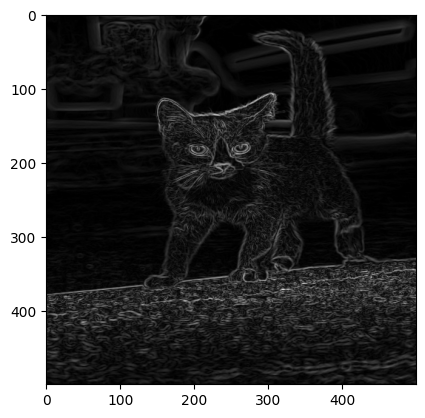

In [36]:
gx, gy, sobel_edges = sobel_edge_detection(np.array(image))
plt.imshow(sobel_edges, cmap = 'gray')

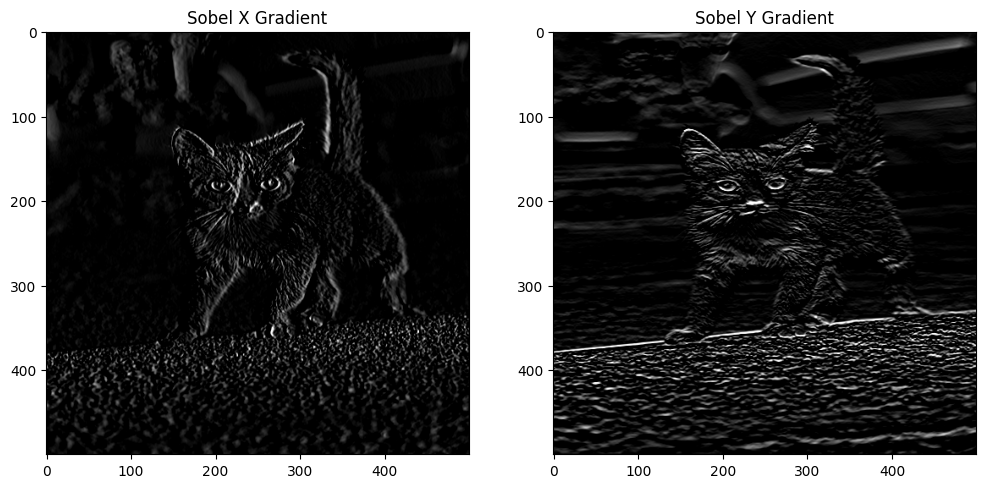

In [37]:
gx_image = Image.fromarray(gx)
gy_image = Image.fromarray(gy)
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Sobel X Gradient")
plt.imshow(gx_image , cmap = 'gray')
plt.subplot(1,2,2)
plt.title("Sobel Y Gradient")
plt.imshow(gy_image , cmap = 'gray')
plt.show()